<a href="https://colab.research.google.com/github/SagiMeir/Simulations4Beginners/blob/RonnyKed-patch-1/Copy_of_sim4beginners.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MAIN**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

sns.set_theme(style="ticks", rc={'axes.labelsize': 14})

In [2]:
x: int = 5 ** (-10)
# hbar is in J * s
hbar: float = 1.05457182 * (10**(-34))
omega: float = (50 * (10**(-3)) * (1.6 * (10**(-19))))/hbar

# omega in hrz
print("Omega (in Hz): " , omega)

# Calculation of mass
mass: float = 6.6335209 * (10**(-26))
print("Mass (in kg): " , mass)

# Energy in J
J: float = 0.5 * (x * omega) ** 2 * mass
print("\nEnergy (in Joules): " , J)

# Energy in eV
eV: float = (6.242 ** (-18)) * J
print("Energy (in eV): " , eV)

Omega (in Hz):  75860172330415.58
Mass (in kg):  6.6335209e-26

Energy (in Joules):  2.0014358253114444e-12
Energy (in eV):  9.671947074605484e-27


In [3]:
from typing import Optional
import numpy as np
import pandas as pd
from scipy.constants import Boltzmann as BOLTZMANN
from scipy.constants import hbar as h_bar

class Simulation:

    def __init__( self,
                 dt:float,
                 temp:float = 298,
                 Nsteps:int = 0,
                 R:Optional[np.ndarray] = None,
                 mass:Optional[float] = None,
                 kind:Optional[list] = None,
                 p:Optional[np.ndarray] = None,
                 F:Optional[np.ndarray] = None,
                 U:Optional[float] = None,
                 K:Optional[float] = None,
                 seed:Optional[int] = 937142,
                 ftype:str = "Harm",
                 step:int = 0,
                 printfreq:int = 1000,
                 xyzname:str = "sim.xyz",
                 fac:float = 1.0,
                 outname:str = "sim.log",
                  dim: int = 1,
                 gamma:float = None,
                  beads: int = None,
                 ) -> None:
        """
        Parameters
        ----------
        dt : float
            Simulation time step.

        temp: float
            The temperature.

        Nsteps : int, optional
            Number of steps to take. The default is 0.

        R : numpy.ndarray, optional
            Particles' positions, Natoms x 3 array. The default is None.

        mass : float, optional
            Particles' masses, Natoms x 1 array. The default is None.

        kind : list of str, optional
            Natoms x 1 list with atom type for printing. The default is None.

        p : numpy.ndarray, optional
            Particles' momenta, Natoms x 3 array. The default is None.

        F : numpy.ndarray, optional
            Particles' forces, Natoms x 3 array. The default is None.

        U : float, optional
            Potential energy . The default is None.

        K : float, optional
            Kinetic energy. The default is None.

        seed : int, optional
            Big number for reproducible random numbers. The default is 937142.

        ftype : str, optional
            String to call the force evaluation method. The default is None.

        step : INT, optional
            Current simulation step. The default is 0.

        printfreq : int, optional
            PRINT EVERY printfreq TIME STEPS. The default is 1000.

        xyzname : TYPE, optional
            DESCRIPTION. The default is "sim.xyz".

        fac : float, optional
            Factor to multiply the positions for printing. The default is 1.0.

        thermo_type: str, optional
            String to call the thermostating evaluation method. The default is None.

        outname : TYPE, optional
            DESCRIPTION. The default is "sim.log".

        Returns
        -------
        None.
        """

        #general
        self.printfreq = printfreq
        self.xyzfile = open( xyzname, 'w' )
        self.outfile = open( outname, 'w' )

        #simulation
        self.dim = dim
        self.gamma = gamma
        self.temp = temp
        self.Nsteps = Nsteps
        self.dt = dt
        self.seed = seed
        self.step = step
        self.fac = fac
        self.beads = beads

        #system
        if R is not None:
            self.R = R
            self.mass = mass
            self.kind = kind
            self.Natoms = self.R.shape[0]
            # self.mass_matrix = np.array( [self.mass,]*3 ).transpose()
        else:
            self.R = np.zeros( (1,3) )
            self.mass = 1.6735575E-27 # H mass in kg as default
            self.kind = ["H"]
            self.Natoms = self.R.shape[0]
            # self.mass_matrix = np.array( [self.mass,]*3 ).transpose()
        if p is not None:
            self.p = p
            self.K = K
        else:
            self.p = np.zeros( (self.Natoms,3) )
            self.K = 0.0

        if F is not None:
            self.F = F
            self.U = U
        else:
            self.F = np.zeros( (self.Natoms,3) )
            self.U = 0.0

        if beads is not None:
          self.beads = beads
          self.R_beads = np.zeros([self.Natoms, self.dim, self.beads])
          self.p_beads = np.zeros([self.Natoms, self.dim, self.beads])
          self.F_beads = np.zeros([self.Natoms, self.dim, self.beads])
          self.F_beads_external = np.zeros([self.Natoms, self.dim, self.beads])
          self.omegaP = ((np.sqrt(self.beads)) * BOLTZMANN * temp)/h_bar
          self.PIMD_xyz = [open(xyzname +'_bead'+ str(bead) + ".xyz", "w") for bead in range(beads)]

        np.random.seed( self.seed )

        #check force type
        if ( ftype == "Harm" or ftype == "Anharm"):
            self.ftype = "eval" + ftype
        else:
            raise ValueError("Wrong ftype value - use Harm or Anharm.")


    def __del__( self ) -> None:
        """
        THIS IS THE DESCTRUCTOR. NOT USUALLY NEEDED IN PYTHON.
        JUST HERE TO CLOSE THE FILES.
        Returns
        -------
        None.
        """
        self.xyzfile.close()
        self.outfile.close()

    def evalForce( self, **kwargs ) -> None:
        """
        THIS FUNCTION CALLS THE FORCE EVALUATION METHOD, BASED ON THE VALUE
        OF FTYPE, AND PASSES ALL OF THE ARGUMENTS (WHATEVER THEY ARE).
        Returns
        -------
        None. Calls the correct method based on self.ftype.
        """
        getattr(self, self.ftype)(**kwargs)

    def dumpThermo( self ) -> None:
        """
        THIS FUNCTION DUMPS THE ENERGY OF THE SYSTEM TO FILE.
        Parameters
        ----------
        R : numpy.ndarray
            Natoms x 3 array with particle coordinates. # noqa
        step : int
            Simulation time step.
        file : _io.TextIOWrapper
            File object to write to. Created using open() in main.py # noqa
        Returns
        -------
        None. # noqa
        """
        if( self.step == 0 ):
            self.outfile.write( "step K U E \n" )

        U_scalar = self.U.item() if isinstance(self.U, np.ndarray) else self.U
        K_scalar = self.K.item() if isinstance(self.K, np.ndarray) else self.K
        E_scalar = self.E.item() if isinstance(self.E, np.ndarray) else self.E


        self.outfile.write( str(self.step) + " " \
                          + "{:.6e}".format(K_scalar) + " " \
                          + "{:.6e}".format(U_scalar) + " " \
                          + "{:.6e}".format(E_scalar) + "\n" )

        self.outfile.flush()

    def dumpXYZ( self ) -> None:
        """
        THIS FUNCTION DUMP THE COORDINATES OF THE SYSTEM IN XYZ FORMAT TO FILE.
        Parameters
        ----------
        R : numpy.ndarray
            Natoms x 3 array with particle coordinates. # noqa
        step : int
            Simulation time step.
        file : _io.TextIOWrapper
            File object to write to. Created using open() in main.py # noqa
        Returns
        -------
        None. # noqa
        """

        self.xyzfile.write( str( self.Natoms ) + "\n")
        self.xyzfile.write( "Step " + str( self.step ) + "\n" )

        for i in range( self.Natoms ):
            self.xyzfile.write( self.kind[i] + " " + \
                              "{:.6e}".format( self.R[i,0]*self.fac ) + " " + \
                              "{:.6e}".format( self.R[i,1]*self.fac ) + " " + \
                              "{:.6e}".format( self.R[i,2]*self.fac ) + "\n" )

        self.xyzfile.flush()

    def dumpXYZ_PIMD(self) -> None:
       for bead in range(self.beads):
          self.PIMD_xyz[bead].write(str(self.Natoms) + "\n")
          self.PIMD_xyz[bead].write("Step " + str(self.step) + "\n")

          for i in range( self.Natoms ):
            line_to_write = self.kind[i]
            for d in range(self.dim):
                line_to_write += " " + "{:.6e}".format( self.R_beads[i, d, bead]*self.fac )
            self.PIMD_xyz[bead].write(line_to_write + "\n")
          self.PIMD_xyz[bead].flush()

    def readXYZ( self, inpname:str ) -> None:
        """
        THIS FUNCTION READS THE INITIAL COORDINATES IN XYZ FORMAT.
        Parameters
        ----------
        inpname : str
                xyz input file to read

        Returns
        -------
        None.
        """

        df = pd.read_csv( inpname, sep=r"\s+", skiprows=2, header=None )

        self.kind = df[ 0 ]
        self.R = df[ [1,2,3] ].to_numpy()
        self.Natoms = self.R.shape[0]


        ################################################################
        ################## NO EDITING ABOVE THIS LINE ##################
        ################################################################

    def CalcKinE( self ):
        """
        THIS FUNCTIONS EVALUATES THE KINETIC ENERGY OF THE SYSTEM.
        Returns
        -------
        None. Sets the value of self.K.
        """
        self.K = (self.p**2).sum()/(2*self.mass)

    def sampleMB( self, removeCM=True ):
        """
        THIS FUNCTIONS SAMPLES INITIAL MOMENTA FROM THE MB DISTRIBUTION.
        IT ALSO REMOVES THE COM MOMENTA, IF REQUESTED.
        Parameters
        ----------
        removeCM : bool, optional
            Remove COM velocity or not. The default is True.
        Returns
        -------
        None. Sets the value of self.p.
        """
        #################################################################
        ##################### YOUR CODE GOES HERE ######################
        ################################################################
        sigma = np.sqrt(self.mass * BOLTZMANN * self.temp)
        self.p = np.random.normal(0.0, sigma, size=(self.Natoms, self.dim))
        if self.beads is not None:
          self.p_beads = np.random.normal(0.0, sigma, size=(self.Natoms, self.dim, self.beads))

        if removeCM:
          p_cm = self.p.mean(axis=0)
          self.p -= p_cm

    def evalF_spring( self, omega:float ):
      self.E_spring = 0.0
      self.F_beads = np.zeros_like(self.R_beads)
      for j in range (self.beads):
        self.F_beads[:, :, j] = - (self.mass * (omega**2)) * (
            2 * self.R_beads[:, :, j]
            - self.R_beads[:, :, (j + 1) % self.beads]
            - self.R_beads[:, :, (j - 1 + self.beads) % self.beads]
        )

        delta_R = self.R_beads[:, :, j] - self.R_beads[:, :, (j + 1) % self.beads]
        self.E_spring += 0.5 * self.mass * (omega**2) * np.sum(delta_R**2)


    def evalHarm( self, omega:float ):
        """
        THIS FUNCTION EVALUATES THE POTENTIAL AND FORCE FOR A HARMONIC TRAP.
        Parameters
        ----------
        omega : float
            The frequency of the trap.
        Returns
        -------
        None. Sets the value of self.F and self.U
        """
        if self.beads is not None:
            total_U_external = 0.0
            self.F_beads_external = np.zeros_like(self.R_beads)
            for bead_idx in range(self.beads):
                r_bead = self.R_beads[:, :, bead_idx]
                total_U_external += ((self.mass/2) * (omega**2) * np.sum(r_bead**2))/self.beads
                self.F_beads_external[:, :, bead_idx] = ((self.mass * omega**2 * r_bead) * (-1))/self.beads
            self.U = total_U_external

        else:
            self.U = (self.mass/2) * (omega**2) * np.sum(self.R**2)
            self.F = (self.mass * omega**2 * self.R) * (-1)

    def VVstep( self, **kwargs ):
        """
        THIS FUNCTIONS PERFORMS ONE VELOCITY VERLET STEP.
        Returns
        -------
        None. Sets self.R, self.p.
        """

        self.p = self.p + self.dt/2 * self.F
        self.R = self.R + self.dt * (self.p/self.mass)
        self.evalForce(**kwargs)
        self.p = self.p + self.dt/2 * self.F

    def VVstep_NVT(self, **kwargs):

      gamma = self.gamma
      m = self.mass
      dim = self.dim
      kBT = BOLTZMANN * self.temp
      dt = self.dt

      exp_fac = np.exp(-self.gamma * self.dt)
      self.sigma = np.sqrt(m * kBT * (1 - np.exp(-2 * self.gamma * dt)))

      self.xi1 = np.random.normal(0.0, 1.0, size=self.p.shape)
      if dim < 3:
          self.xi1[:,dim:] = np.zeros(shape = self.p.shape)[:,dim:]
      self.p = exp_fac * self.p + self.sigma * self.xi1

      self.VVstep(**kwargs)

      self.xi2 = np.random.normal(0.0, 1.0, size=self.p.shape)
      if dim < 3:
          self.xi2[:,dim:] = np.zeros(shape = self.p.shape)[:,dim:]
      self.p = exp_fac * self.p + self.sigma * self.xi2


    def VVStep_Pimd(self, **kwargs):

      total_force_on_beads = self.F_beads_external + self.F_beads

      self.p_beads = self.p_beads + self.dt/2 * total_force_on_beads
      self.R_beads = self.R_beads + self.dt * (self.p_beads/self.mass)
      self.evalForce(**kwargs)
      self.evalF_spring(self.omegaP)


      total_force_on_beads = self.F_beads_external + self.F_beads
      self.p_beads = self.p_beads + self.dt/2 * total_force_on_beads

    def VVStep_Pimd_NVT(self, **kwargs):

      gamma = self.gamma
      m = self.mass
      dim = self.dim
      kBT = BOLTZMANN * self.temp
      dt = self.dt

      exp_fac = np.exp(-gamma * dt)
      sigma = np.sqrt(m * kBT * (1 - np.exp(-2 * gamma * dt)))

      xi1 = np.random.normal(0.0, 1.0, size=self.p_beads.shape)

      self.p_beads = exp_fac * self.p_beads + sigma * xi1

      self.VVStep_Pimd(**kwargs)

      xi2 = np.random.normal(0.0, 1.0, size=self.p_beads.shape)

      self.p_beads = exp_fac * self.p_beads + sigma * xi2

    def run( self, **kwargs ):
        """
        THIS FUNCTION DEFINES WHAT THE SIMULATION DOES, GIVEN AN INSTANCE OF
        THE SIMULATION CLASS.
        1. EVALUATE THE FORCES (USE evaluateForce() AND PASS A DICTIONARY
                                    WHICH ONLY CONTAINS THE PARAMETERS FOR THE
                                    FORCE EVALUATION METHOD).
        2. PROPAGATE FOR N TIME STEPS USING THE VELOCITY VERLET ALGORITHM.
        3. YOU WILL ALSO NEED TO PRINT THE COORDINATES AND ENERGIES EVERY
        PRINTFREQ TIME STEPS TO THEIR RESPECTIVE FILES, xyzfile AND outfile.
        Returns
        -------
        None.
        """

        self.evalForce(**kwargs)
        self.CalcKinE()
        self.E = self.K + self.U

        for step in range(self.Nsteps):
            self.step = step
            self.VVstep(**kwargs)
            self.CalcKinE()
            self.E = self.K + self.U

            if step % self.printfreq == 0:
              self.dumpXYZ()
              self.dumpThermo()

    def run_NVT(self, **kwargs):

      self.sampleMB()
      self.evalForce(**kwargs)
      self.CalcKinE()
      self.E = self.K + self.U

      for step in range(self.Nsteps):
        self.step = step
        self.VVstep_NVT(**kwargs)
        self.CalcKinE()
        self.E = self.K + self.U

        if step % self.printfreq == 0:
          self.dumpXYZ()
          self.dumpThermo()


    def run_pimd_NVE(self, **kwargs):
      self.sampleMB()
      self.evalForce(**kwargs)
      self.evalF_spring(self.omegaP)
      self.K = np.sum(self.p_beads**2) / (2 * self.mass)
      self.E = self.K + self.U + self.E_spring

      for step in range(self.Nsteps):
        self.step = step
        self.VVStep_Pimd(**kwargs)
        self.K = np.sum(self.p_beads**2) / (2 * self.mass)
        self.E = self.K + self.U + self.E_spring

        if step % self.printfreq == 0:
            self.dumpXYZ_PIMD()
            self.dumpThermo()

    def run_pimd_NVT(self, **kwargs):

      self.sampleMB()
      self.p_beads -= self.p_beads.mean(axis=2, keepdims=True)

      self.evalForce(**kwargs)
      self.evalF_spring(self.omegaP)
      self.K = np.sum(self.p_beads**2) / (2 * self.mass)
      self.E = self.K + self.U + self.E_spring

      for step in range(self.Nsteps):
        self.step = step
        self.VVStep_Pimd_NVT(**kwargs)
        self.evalForce(**kwargs)
        self.evalF_spring(self.omegaP)
        self.K = np.sum(self.p_beads**2) / (2 * self.mass)
        self.E = self.K + self.U + self.E_spring

        if step % self.printfreq == 0:
            self.dumpXYZ_PIMD()
            self.dumpThermo()

# The Harmonic Oscillator

Several simulations

In [ ]:
for i, dt in enumerate(np.linspace(0.5e-15, 1.0e-15, 7)):

  mySim = Simulation(dt = dt, Nsteps = 10000, printfreq = 150, step = 0,  outname = "sim"+str(i)+".log", xyzname = "sim"+str(i)+".xyz", gamma = omega) # Pass omega as gamma for NVT
  mySim.R = np.array([[5.0, 0.0, 0.0]])
  mySim.kind = ['Ar']
  mySim.Natoms = 1
  mySim.mass = 6.6335209e-26

  params = {"omega": 7.586017233041558e13}
  mySim.evalForce(**params)

  mySim.run_NVT(**params)

  from google.colab import files
  files.download("sim"+str(i)+".log")
  files.download("sim"+str(i)+".xyz")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Figure 01

Max Δt with difference smaller than 0.1%: 8.333333333333334e-16


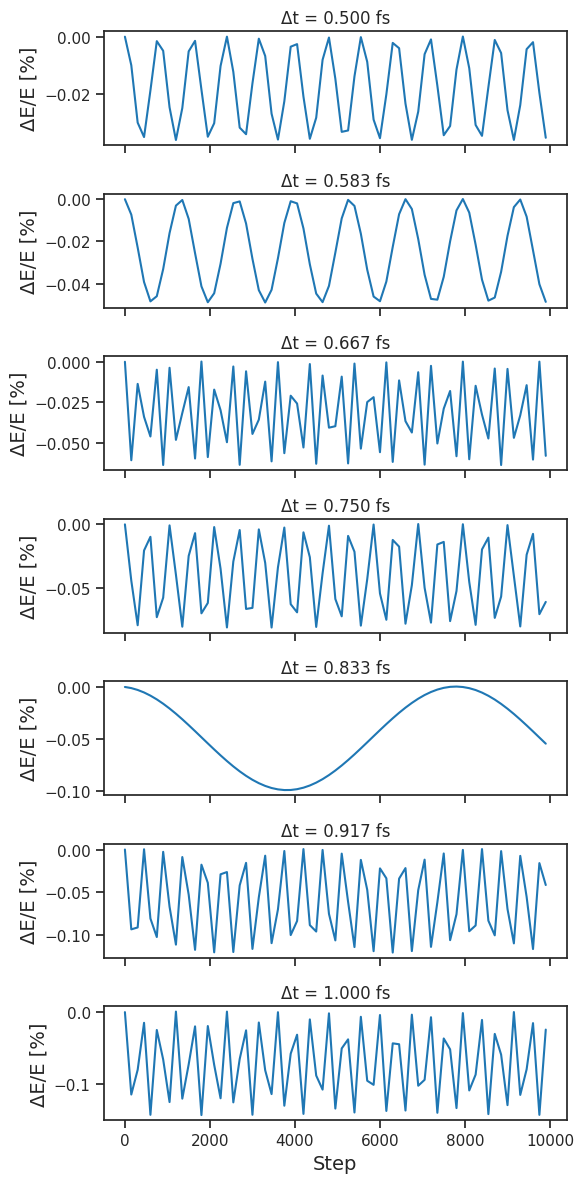

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", rc={'axes.labelsize': 14})

beforeDt: float = 0
found: bool = False

dt_values = np.linspace(0.5e-15, 1.0e-15, 7)

for i, dt in enumerate(dt_values):
    df = pd.read_csv(f"sim{i}.log", sep=r'\s+')

    energy = df["E"]
    initial_energy = energy.iloc[0]
    diff_percent = np.abs((energy - initial_energy) * 100 / initial_energy)
    max_diff = diff_percent.max()

    if max_diff >= 0.1 and not found:
        print("Max Δt with difference smaller than 0.1%:", beforeDt)
        found = True
        break

    beforeDt = dt

fig, ax = plt.subplots(len(dt_values), 1, figsize = (6, 12), sharex = True)

for i, dt in enumerate(dt_values):
    df = pd.read_csv(f"sim{i}.log", sep=r'\s+')
    step = df["step"]
    energy = df["E"]
    initial_energy = energy.iloc[0]
    delta_percent = (energy - initial_energy) * 100 / initial_energy

    ax[i].plot(step, delta_percent, color = 'tab:blue', linewidth = 1.5)
    ax[i].set_title(f"\u0394t = {dt * 1e15:.3f} fs")
    ax[i].set_ylabel("\u0394E/E [%]")


ax[-1].set_xlabel("Step")
plt.tight_layout()
plt.show()

Figure 02

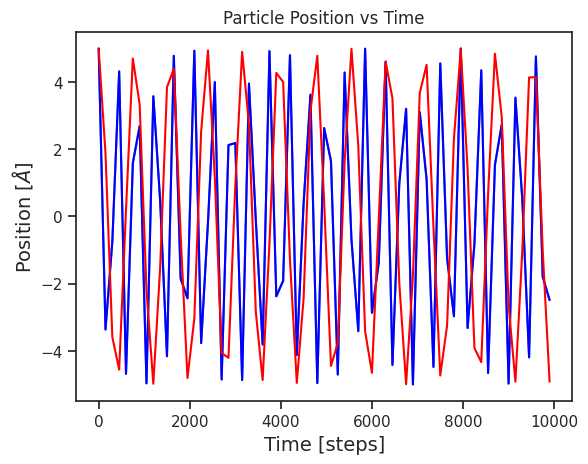

In [ ]:
import matplotlib.pyplot as plt
import math

time = []
posX = []

with open("sim3.xyz", "r") as f:
    while True:
        lines = [f.readline() for _ in range(3)]
        if not all(lines):
            break
        t = float(lines[1].strip().split()[1])
        x = float(lines[2].strip().split()[1])
        time.append(t)
        posX.append(x)

calc = []

for i in range(len(time)):
    calc.append(posX[0] * math.cos(omega * time[i] * dt))

plt.plot(time, posX, label="Position")
plt.xlabel("Time [steps]")
plt.ylabel(r"Position [$\AA$]")
plt.title("Particle Position vs Time")
plt.plot(time, posX, color = "blue", label = "Simulation movement")
plt.plot(time, calc, color = "red", label = "Theoreticsl movement")
plt.show()

Figure 03

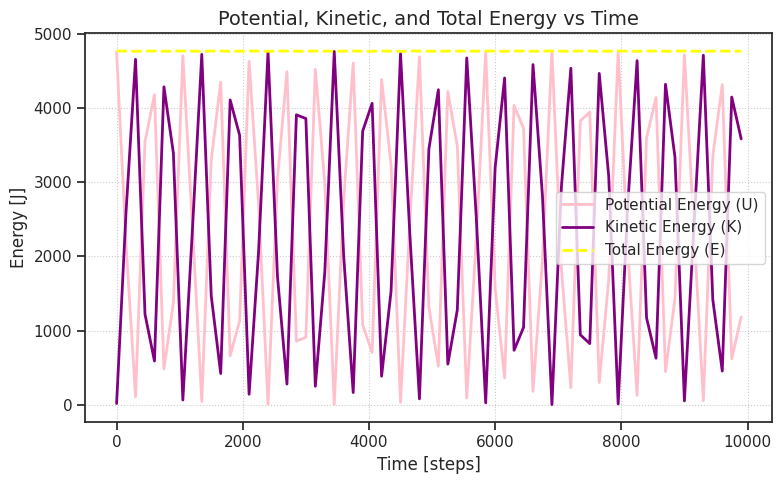

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style = "ticks",rc={'axes.labelsize':14},palette='tab10')

df = pd.read_csv("sim3.log", sep = r'\s+')

plt.figure(figsize = (8, 5))
plt.title("Potential, Kinetic, and Total Energy vs Time", fontsize = 14)
plt.xlabel("Time [steps]", fontsize = 12)
plt.ylabel("Energy [J]", fontsize = 12)
plt.plot(df['step'], df['U'], label = "Potential Energy (U)", color = "pink", linewidth = 2)
plt.plot(df['step'], df['K'], label="Kinetic Energy (K)", color = "purple", linewidth = 2)
plt.plot(df['step'], df['E'], label = "Total Energy (E)", color = "yellow", linewidth = 2, linestyle = "--")
plt.legend(fontsize = 11)
plt.grid(True, linestyle = ":", linewidth = 0.8)
plt.tight_layout()
plt.show()

Figure 4

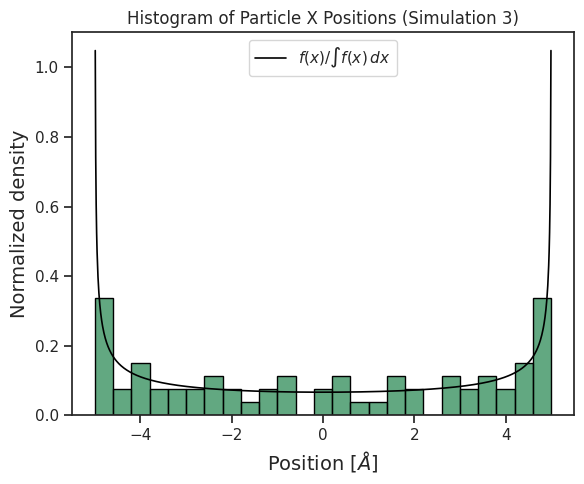

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks", rc={"axes.labelsize": 14}, palette="tab10")

omega = 75860172330415.58
x = np.linspace(-4.99, 4.99, 1000)
fx = 1/(omega * np.sqrt((5**2) - (x**2)))
s = np.trapezoid(fx, x)
fx_norm = fx / s

posX = []
with open("sim3.xyz") as f:
  while True:
      f.readline()
      comment_line = f.readline()
      if not comment_line:
          break

      line = f.readline()
      if not line:
          break

      fields = line.strip().split()
      if len(fields) >= 2:
            posX.append(float(fields[1]))

  plt.figure(figsize=(6, 5))
  sns.histplot(posX, bins=25, color='seagreen', edgecolor='black', stat='density')
  plt.plot(x, fx_norm, color='black', linewidth=1.2, label=r"$f(x)/\int f(x)\,dx$")
  plt.xlabel(r"Position [$\AA$]")
  plt.ylabel("Normalized density")
  plt.title("Histogram of Particle X Positions (Simulation 3)")
  plt.legend()
  plt.tight_layout()
  plt.show()

Figure 05

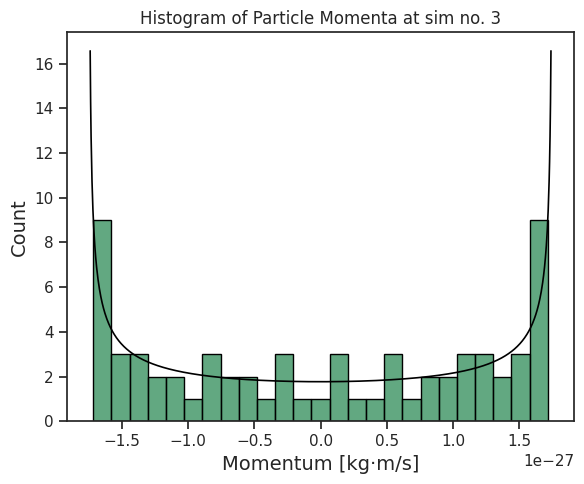

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", rc={"axes.labelsize": 14}, palette="tab10")

omega = 7.586017233041558e13
p_vals = np.linspace(-1.74 * 1e-27, 1.74 * 1e-27, 1000)
fx = 1 / (omega * np.sqrt((1.75e-27**2) - (p_vals**2)))
s = np.trapezoid(fx, p_vals)
fx_norm = fx / s

positions = []
times = []
mass = 6.6335209e-26

positions = []
times = []
with open("sim3.xyz", "r") as f:
  while True:
      lines = [f.readline() for _ in range(3)]
      if not all(lines):
          break
      try:
          t = float(lines[1].strip().split()[1])
          x = float(lines[2].strip().split()[1])
          times.append(t)
          positions.append(x)
      except (IndexError, ValueError):
          continue

positions = np.array(positions)
times = np.array(times)

unique_mask = np.diff(times, prepend=np.nan) > 0
positions = positions[unique_mask]
times = times[unique_mask]

velocities = np.gradient(positions, times)
momenta = mass * velocities

plt.figure(figsize=(6, 5))


plt.plot(p_vals, fx_norm * len(momenta) * (np.max(momenta) - np.min(momenta)) / 25, color='black', linewidth=1.2, label=r"$f(p)$ Scaled to Count")
sns.histplot(momenta, bins=25, color='seagreen', edgecolor='black')
plt.xlabel("Momentum [kg·m/s]")
plt.ylabel("Count")
plt.title("Histogram of Particle Momenta at sim no. 3")
plt.tight_layout()
plt.show()

# NVT Harmonic Oscillator

Simulations for gamma

In [ ]:
mySim = Simulation(dt = 8.333333333333334e-16, dim = 1, Nsteps = 10000, printfreq = 150, step = 0,  outname = "sim_NVT.log", xyzname="sim_NVT.xyz", gamma = omega)
mySim.run_NVT(**{"omega": 75860172330415.58})

In [ ]:
mySim = Simulation(dt = 8.333333333333334e-16, dim = 1, Nsteps = 10000, printfreq = 150, step = 0,  outname = "sim_NVT1.log", xyzname="sim_NVT1.xyz", gamma = 0.0000001 * omega)
mySim.run_NVT(**{"omega": 75860172330415.58})

In [ ]:
mySim = Simulation(dt = 8.333333333333334e-16, dim = 1, Nsteps = 10000, printfreq = 150, step = 0,  outname = "sim_NVT2.log", xyzname="sim_NVT2.xyz", gamma = 10000000 * omega)
mySim.run_NVT(**{"omega": 75860172330415.58})

Ideal temperature

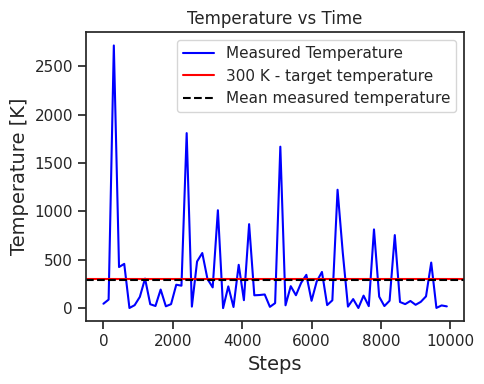

In [ ]:
t_target = 300
df = pd.read_csv("sim_NVT.log", sep = r'\s+')
temp = (2 * df["K"].values)/(BOLTZMANN)


fig, ax = plt.subplots(figsize = (5, 4))
ax.plot(df["step"], temp, color = 'blue', label = 'Measured Temperature')
ax.axhline(t_target, color = 'red', label = '300 K - target temperature')
ax.set_ylabel("Temperature [K]")
ax.set_xlabel("Steps")
ax.axhline(temp.mean(), color = 'black', linestyle = '--', label = 'Mean measured temperature')
ax.set_title("Temperature vs Time")
ax.legend()
plt.tight_layout()
plt.show()

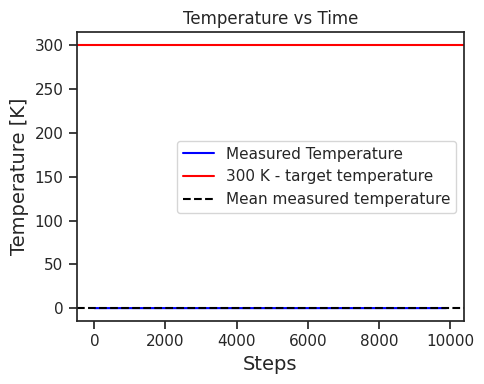

In [ ]:
t_target = 300
df = pd.read_csv("sim_NVT1.log", sep = r'\s+')
temp = (2 * df["K"].values)/(BOLTZMANN)


fig, ax = plt.subplots(figsize = (5, 4))
ax.plot(df["step"], temp, color = 'blue', label = 'Measured Temperature')
ax.axhline(t_target, color = 'red', label = '300 K - target temperature')
ax.set_ylabel("Temperature [K]")
ax.set_xlabel("Steps")
ax.axhline(temp.mean(), color = 'black', linestyle = '--', label = 'Mean measured temperature')
ax.set_title("Temperature vs Time")
ax.legend()
plt.tight_layout()
plt.show()

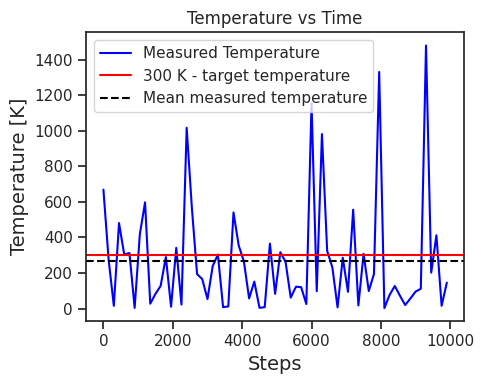

In [ ]:
t_target = 300
df = pd.read_csv("sim_NVT2.log", sep = r'\s+')
temp = (2 * df["K"].values)/(BOLTZMANN)


fig, ax = plt.subplots(figsize = (5, 4))
ax.plot(df["step"], temp, color = 'blue', label = 'Measured Temperature')
ax.axhline(t_target, color = 'red', label = '300 K - target temperature')
ax.set_ylabel("Temperature [K]")
ax.set_xlabel("Steps")
ax.axhline(temp.mean(), color = 'black', linestyle = '--', label = 'Mean measured temperature')
ax.set_title("Temperature vs Time")
ax.legend()
plt.tight_layout()
plt.show()

# PIMD

Several simulations

In [ ]:
omega = omega

beads = 4
temp = 298
omega_trap = (np.sqrt(beads) * BOLTZMANN * temp) / h_bar

largest_frequency = max(omega_trap, omega)

dt_max_recommended = 1 / (100 * largest_frequency)

dt_min_for_sim = dt_max_recommended * 0.1
dt_values_for_sim = np.linspace(dt_min_for_sim, dt_max_recommended, 7)

for i, dt in enumerate(dt_values_for_sim):

    mySim = Simulation(dt=dt, Nsteps=30000, printfreq=150, step=0, outname="sim_pimd"+str(i)+".log", xyzname="sim_pimd"+str(i)+".xyz", beads = 4)
    mySim.Natoms = 1
    mySim.mass = 6.6335209e-26
    mySim.kind = ['Ar']

    for j in range(mySim.beads):
        mySim.R_beads[:, :, j] = np.array([[5.0, 0.0, 0.0]])

    mySim.sampleMB()
    params = {"omega": omega_trap}

    mySim.run_pimd_NVE(**params)

    # Removed files.download() to keep logs in Colab environment

The energy save over time

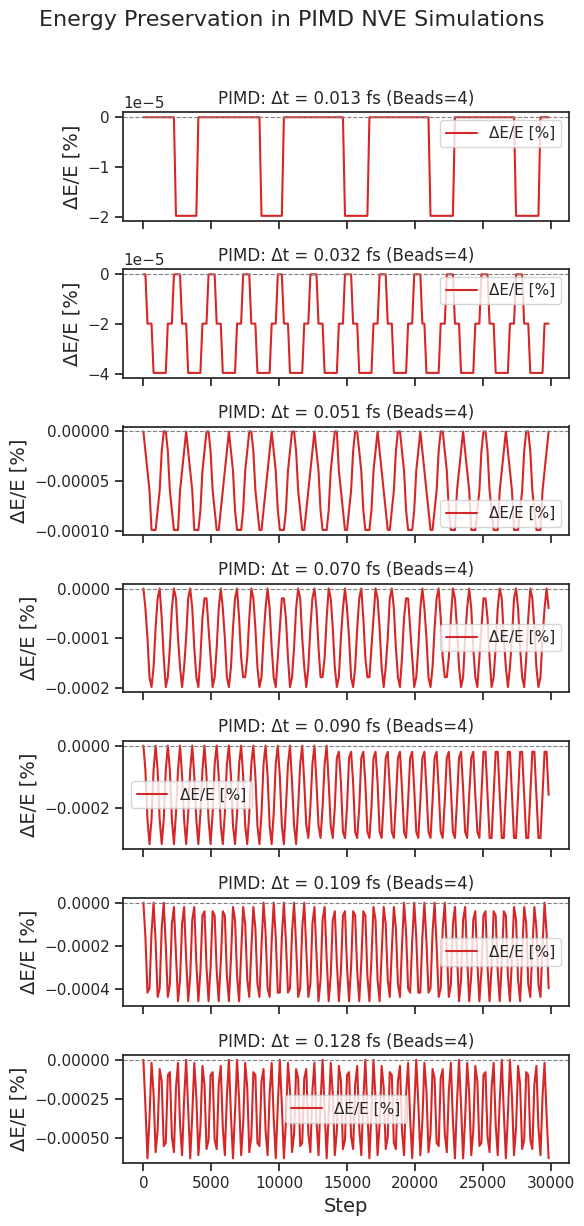

In [ ]:
dt_values = np.linspace(dt_min_for_sim, dt_max_recommended, 7)

fig, ax = plt.subplots(len(dt_values), 1, figsize=(6, 12), sharex=True)

for i, dt in enumerate(dt_values):
    log_filename = f"sim_pimd{i}.log"
    try:
        df = pd.read_csv(log_filename, sep=r'\s+')
    except FileNotFoundError:
        print(f"Warning: {log_filename} not found. Skipping.")
        continue

    energy = df["E"]
    initial_energy = energy.iloc[0]
    delta_percent = (energy - initial_energy) * 100 / initial_energy

    ax[i].plot(df["step"], delta_percent, color='tab:red', linewidth=1.5, label="\u0394E/E [%]")
    ax[i].set_title(f"PIMD: \u0394t = {dt * 1e15:.3f} fs (Beads=4)")
    ax[i].set_ylabel("\u0394E/E [%]")
    ax[i].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax[i].legend()

ax[-1].set_xlabel("Step")
plt.suptitle("Energy Preservation in PIMD NVE Simulations", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

# PIMD NVT

In [ ]:
omega = omega

beads = 4
omega_trap = (np.sqrt(beads) * BOLTZMANN * temp) / h_bar

largest_frequency = max(omega_trap, omega)

300K

In [ ]:
mySim = Simulation(dt = 1e-15, mass = mass, dim = 3, Nsteps = 10000, printfreq = 150, step = 0, temp = 300, outname = "sim_pimd_NVT.log", xyzname="sim_pimd_NVT.xyz", gamma = largest_frequency, beads = 4)
mySim.run_pimd_NVT(**{"omega": omega})

200K

In [ ]:
mySim = Simulation(dt = 1e-15, mass = mass, dim = 3, temp = 200, Nsteps = 10000, printfreq = 150, step = 0,  outname = "sim_pimd_NVT1.log", xyzname="sim_pimd_NVT1.xyz", gamma = largest_frequency, beads = 4)
mySim.run_pimd_NVT(**{"omega": omega})

Simulation for different temperatures

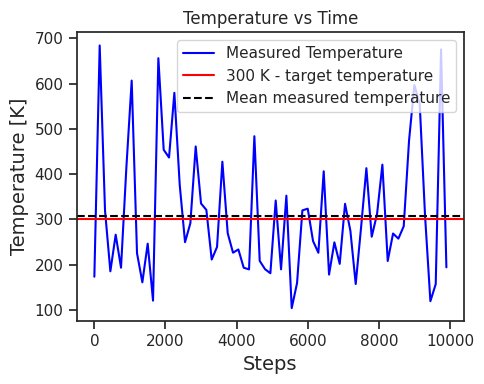

In [ ]:
t_target = 300
df = pd.read_csv("sim_pimd_NVT.log", sep = r'\s+')

temp = (2 * df["K"].values) / (12 * BOLTZMANN)


fig, ax = plt.subplots(figsize = (5, 4))
ax.plot(df["step"], temp, color = 'blue', label = 'Measured Temperature')
ax.axhline(t_target, color = 'red', label = '300 K - target temperature')
ax.set_ylabel("Temperature [K]")
ax.set_xlabel("Steps")
ax.axhline(temp.mean(), color = 'black', linestyle = '--', label = 'Mean measured temperature')
ax.set_title("Temperature vs Time")
ax.legend()
plt.tight_layout()
plt.show()

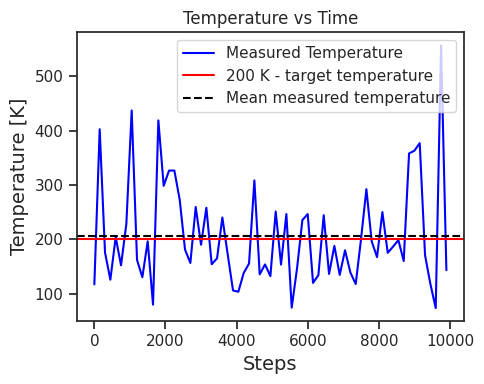

In [ ]:
t_target = 200
df = pd.read_csv("sim_pimd_NVT1.log", sep = r'\s+')

temp = (2 * df["K"].values) / (12 * BOLTZMANN)


fig, ax = plt.subplots(figsize = (5, 4))
ax.plot(df["step"], temp, color = 'blue', label = 'Measured Temperature')
ax.axhline(t_target, color = 'red', label = '200 K - target temperature')
ax.set_ylabel("Temperature [K]")
ax.set_xlabel("Steps")
ax.axhline(temp.mean(), color = 'black', linestyle = '--', label = 'Mean measured temperature')
ax.set_title("Temperature vs Time")
ax.legend()
plt.tight_layout()
plt.show()

Quantum energy over time

In [ ]:
print(temp)

96.5729399983112


In [ ]:
from google.colab import files

temp = (h_bar * omega) / (6 * BOLTZMANN)

P_values = [4, 8, 16, 32, 64]

seeds = range(1,11)

U_final = []

for P in P_values:

    omegaP = (np.sqrt(P) * BOLTZMANN * temp) / h_bar

    largest_frequency = max(omegaP, omega)

    dt = 1 / (100 * largest_frequency)

    print(f"\nP={P}: dt={dt:.3e}, omegaP={omegaP:.3e}")

    U_for_this_P = []

    for seed in seeds:

        mySim = Simulation(dt=dt, temp=temp, mass=mass, dim=1, beads=P, gamma=largest_frequency, Nsteps=100000, printfreq=1000, seed=seed, outname=f"pimd_P{P}_seed{seed}.log", xyzname=f"pimd_P{P}_seed{seed}.xyz")
        mySim.R_beads[:] = 0.0
        mySim.run_pimd_NVT(omega=omega)
        df = pd.read_csv(f"pimd_P{P}_seed{seed}.log", sep=r"\s+")
        U = df["U"].values
        equil = int(0.2 * len(U))
        U_avg = U[equil:].mean()
        U_for_this_P.append(U_avg)
        print(f"P={P}, seed={seed}, <U>={U_avg:.3e}")

    U_mean = np.mean(U_for_this_P)
    U_final.append(U_mean)
    print(f"\nFINAL AVERAGE FOR P={P}: {U_mean:.3e}")

beta = 1 / (BOLTZMANN * temp)

U_theory = ((h_bar * omega / 4)/ np.tanh(beta * h_bar * omega / 2))
print(f"\nTheoretical value: {U_theory:.3e}")


P=4: dt=1.318e-16, omegaP=2.529e+13
P=4, seed=1, <U>=1.778e-21
P=4, seed=2, <U>=1.715e-21
P=4, seed=3, <U>=1.698e-21
P=4, seed=4, <U>=1.513e-21
P=4, seed=5, <U>=1.580e-21
P=4, seed=6, <U>=1.918e-21
P=4, seed=7, <U>=1.510e-21
P=4, seed=8, <U>=1.710e-21
P=4, seed=9, <U>=1.674e-21
P=4, seed=10, <U>=1.567e-21

FINAL AVERAGE FOR P=4: 1.666e-21

P=8: dt=1.318e-16, omegaP=3.576e+13
P=8, seed=1, <U>=1.775e-21
P=8, seed=2, <U>=1.972e-21
P=8, seed=3, <U>=1.990e-21
P=8, seed=4, <U>=1.901e-21
P=8, seed=5, <U>=1.923e-21
P=8, seed=6, <U>=1.982e-21
P=8, seed=7, <U>=1.699e-21
P=8, seed=8, <U>=1.925e-21
P=8, seed=9, <U>=2.084e-21
P=8, seed=10, <U>=2.019e-21

FINAL AVERAGE FOR P=8: 1.927e-21

P=16: dt=1.318e-16, omegaP=5.057e+13
P=16, seed=1, <U>=2.017e-21
P=16, seed=2, <U>=2.255e-21
P=16, seed=3, <U>=2.117e-21
P=16, seed=4, <U>=1.903e-21
P=16, seed=5, <U>=2.019e-21
P=16, seed=6, <U>=2.129e-21
P=16, seed=7, <U>=2.054e-21
P=16, seed=8, <U>=1.938e-21
P=16, seed=9, <U>=2.125e-21
P=16, seed=10, <U>=1.875e-

In [27]:
import numpy as np
import pandas as pd
from scipy.constants import Boltzmann as BOLTZMANN
from scipy.constants import hbar as h_bar

temp = (h_bar * omega) / (6 * BOLTZMANN)
seeds = range(1,11)
U_final = []

for P in P_values:
    U_for_this_P = []
    for seed in seeds:
        log_filename = f"pimd_P{P}_seed{seed}.log"
        df = pd.read_csv(log_filename, sep=r"\s+")
        U = df["U"].values
        equil = int(0.2 * len(U))
        U_avg = U[equil:].mean()
        U_for_this_P.append(U_avg)

    if U_for_this_P:
        U_mean = np.mean(U_for_this_P)
        U_final.append(U_mean)

beta = 1 / (BOLTZMANN * temp)
U_theory = ((h_bar * omega / 4)/ np.tanh(beta * h_bar * omega / 2))

FileNotFoundError: [Errno 2] No such file or directory: 'pimd_P4_seed1.log'

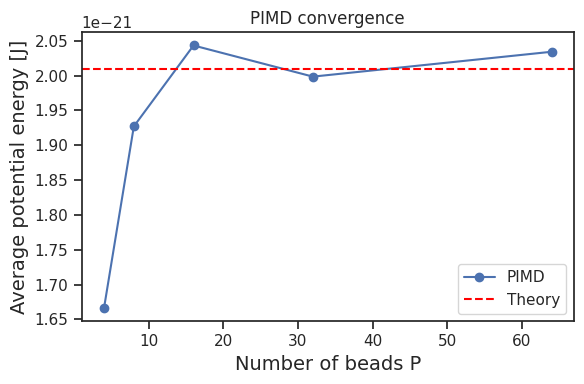

In [ ]:
plt.figure(figsize=(6,4))

plt.plot(
    P_values,
    U_final,
    'o-',
    label='PIMD'
)

plt.axhline(
    U_theory,
    color='red',
    linestyle='--',
    label='Theory'
)

plt.xlabel("Number of beads P")

plt.ylabel("Average potential energy [J]")

plt.title(r"PIMD convergence")

plt.legend()

plt.tight_layout()

plt.show()

# RPMD

In [7]:
steps = [1000, 10000, 50000, 100000, 200000, 500000, 600000, 700000, 800000, 900000]
P_fixed = 64
all_download_files = []

for i, step in enumerate(steps):
    xyz_filename = f"sim_pimd_NVE_P{P_fixed}_steps{step}.xyz"
    log_filename = f"sim_pimd_NVE_P{P_fixed}_steps{step}.log"

    mySim = Simulation(dt = 1e-15, mass = mass, dim = 1, beads = P_fixed, Nsteps = step, printfreq = 1000, outname=log_filename, xyzname=xyz_filename, temp = 96.5729399983112
)
    mySim.Natoms = 1
    mySim.kind = ['Ar']
    mySim.R_beads[:] = 0.0
    mySim.run_pimd_NVE(omega = omega)

    all_download_files.append(log_filename)
    all_download_files.append(xyz_filename)

In [5]:
import numpy as np
P_values = [4, 8, 16, 32, 64]
U_final = [ 1.666e-21, 1.927e-21, 2.043e-21, 1.998e-21, 2.034e-21]
for p_val, avg_u in zip(P_values, U_final):
    print(f"P={p_val}: {avg_u:.3e} J")

overall_average_of_averages = np.mean(U_final)

print(f"\nOverall average of the average potential energies: {overall_average_of_averages:.3e} J")

P=4: 1.666e-21 J
P=8: 1.927e-21 J
P=16: 2.043e-21 J
P=32: 1.998e-21 J
P=64: 2.034e-21 J

Overall average of the average potential energies: 1.934e-21 J


# Delete all files

In [89]:
import os

# Get a list of all files in the current directory
files_in_directory = os.listdir('.')

# Filter for .xyz files and delete them
for file in files_in_directory:
    if file.endswith('.xyz'):
        os.remove(file)

Deleted: sim_pimd_NVE_P64_steps10000.xyz_bead63.xyz
Deleted: sim_pimd_NVE_P64_steps10000.xyz_bead23.xyz
Deleted: sim_pimd_NVE_P64_steps200000.xyz_bead19.xyz
Deleted: sim_pimd_NVE_P64_steps50000.xyz_bead14.xyz
Deleted: sim_pimd_NVE_P64_steps200000.xyz_bead58.xyz
Deleted: sim_pimd_NVE_P64_steps500000.xyz
Deleted: sim_pimd_NVE_P64_steps200000.xyz_bead59.xyz
Deleted: sim_pimd_NVE_P64_steps50000.xyz_bead54.xyz
Deleted: sim_pimd_NVE_P64_steps800000.xyz_bead21.xyz
Deleted: sim_pimd_NVE_P64_steps200000.xyz_bead14.xyz
Deleted: sim_pimd_NVE_P64_steps10000.xyz_bead35.xyz
Deleted: sim_pimd_NVE_P64_steps600000.xyz
Deleted: sim_pimd_NVE_P64_steps900000.xyz_bead37.xyz
Deleted: sim_pimd_NVE_P64_steps200000.xyz_bead4.xyz
Deleted: sim_pimd_NVE_P64_steps700000.xyz_bead29.xyz
Deleted: sim_pimd_NVE_P64_steps700000.xyz_bead48.xyz
Deleted: sim_pimd_NVE_P64_steps700000.xyz_bead45.xyz
Deleted: sim_pimd_NVE_P64_steps700000.xyz_bead60.xyz
Deleted: sim_pimd_NVE_P64_steps200000.xyz_bead17.xyz
Deleted: sim_pimd_NVE

In [90]:
import os

# Get a list of all files in the current directory
files_in_directory = os.listdir('.')

# Filter for .log files and delete them
for file in files_in_directory:
    if file.endswith('.log'):
        os.remove(file)


Deleted: sim_pimd_NVE_P64_steps900000.log
Deleted: sim_pimd_NVE_P64_steps50000.log
Deleted: sim_pimd_NVE_P64_steps500000.log
Deleted: sim_pimd_NVE_P64_steps800000.log
Deleted: sim_pimd_NVE_P64_steps100000.log
Deleted: sim_pimd_NVE_P64_steps600000.log
Deleted: sim_pimd_NVE_P64_steps200000.log
Deleted: sim_pimd_NVE_P64_steps700000.log
Deleted: sim_pimd_NVE_P64_steps10000.log
Deleted: sim_pimd_NVE_P64_steps1000.log
All .log files have been deleted.


In [91]:
import os

files_in_current_directory = os.listdir('.')

for file_name in files_in_current_directory:
    if file_name.endswith(('.xyz')):
        os.remove(file_name)
        print(f"Deleted: {file_name}")

print("All .xyz and .log files have been removed.")

All .xyz and .log files have been removed.


In [92]:
import os
files_in_current_directory = os.listdir('.')

for file_name in files_in_current_directory:
    if file_name.startswith('pimd'):
        try:
            os.remove(file_name)
            print(f"Deleted: {file_name}")
        except OSError as e:
            print(f"Error deleting {file_name}: {e}")

print("Deletion process complete.")

Deletion process complete.


# Download all files

In [9]:
!zip -r my_files.zip /content
from google.colab import files
files.download("my_files.zip")

  adding: content/ (stored 0%)
  adding: content/.config/ (stored 0%)
  adding: content/.config/default_configs.db (deflated 98%)
  adding: content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db (deflated 97%)
  adding: content/.config/logs/ (stored 0%)
  adding: content/.config/logs/2026.06.04/ (stored 0%)
  adding: content/.config/logs/2026.06.04/13.32.38.346437.log (deflated 57%)
  adding: content/.config/logs/2026.06.04/13.32.39.344962.log (deflated 57%)
  adding: content/.config/logs/2026.06.04/13.32.21.210570.log (deflated 58%)
  adding: content/.config/logs/2026.06.04/13.32.18.735754.log (deflated 86%)
  adding: content/.config/logs/2026.06.04/13.32.02.654775.log (deflated 58%)
  adding: content/.config/logs/2026.06.04/13.31.42.499627.log (deflated 92%)
  adding: content/.config/.last_opt_in_prompt.yaml (stored 0%)
  adding: content/.config/.last_update_check.json (deflated 22%)
  adding: content/.config/active_config (stored 0%)
  adding: content/.config

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>